In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df1 = pd.read_csv("06-2024.csv")
df2 = pd.read_csv("07-2024.csv")
df3 = pd.read_csv("08-2024.csv")
df4 = pd.read_csv("09-2024.csv")
df5 = pd.read_csv("10-2024.csv")
df6 = pd.read_csv("11-2024.csv")
df7 = pd.read_csv("12-2024.csv")

In [5]:
df = pd.concat([df1,df2,df3,df4,df5,df6,df7], ignore_index=True)

In [9]:
df

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,53721402546,2024-06-01 09:06,Outbound,00:02:14,NaN,Oliver Martin
1,53721656442,2024-06-01 09:25,Outbound,00:00:30,NaN,Garrett Evans
2,53721997654,2024-06-01 10:00,Outbound,00:24:07,NaN,Keith Antonio
3,53722303027,2024-06-01 10:07,NaN,00:27:46,NaN,Sam Steindorf
4,53721762885,2024-06-01 10:16,Outbound,00:00:27,NaN,Garrett Evans
...,...,...,...,...,...,...
57730,67933901635,2024-12-31 18:54,Outbound,00:00:00,NaN,Tyler Smith
57731,67923792812,2024-12-31 18:54,Outbound,00:00:00,NaN,Tyler Smith
57732,67939743633,2024-12-31 19:00,NaN,NaN,NaN,Boston Hoppman
57733,67914656796,2024-12-31 19:03,NaN,00:31:46,NaN,Adonis Baybayan


In [11]:
df1 = df.drop(columns=['hs_call_outcome', 'Record ID'])

In [13]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 57735 entries, 0 to 57734
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Activity date         57735 non-null  str  
 1   Call direction        45068 non-null  str  
 2   Call duration         47626 non-null  str  
 3   Activity assigned to  56350 non-null  str  
dtypes: str(4)
memory usage: 4.0 MB


In [20]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

In [22]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 57735 entries, 0 to 57734
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         57735 non-null  datetime64[us]
 1   Call direction        45068 non-null  str           
 2   Call duration         47626 non-null  str           
 3   Activity assigned to  56350 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 3.1 MB


# Call Count per day

In [25]:
df2 = df1.copy()

In [27]:
df2['date'] = df2['Activity date'].dt.date

In [29]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2024-06-01 09:06:00,Outbound,00:02:14,Oliver Martin,2024-06-01
1,2024-06-01 09:25:00,Outbound,00:00:30,Garrett Evans,2024-06-01
2,2024-06-01 10:00:00,Outbound,00:24:07,Keith Antonio,2024-06-01
3,2024-06-01 10:07:00,NaN,00:27:46,Sam Steindorf,2024-06-01
4,2024-06-01 10:16:00,Outbound,00:00:27,Garrett Evans,2024-06-01


In [31]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

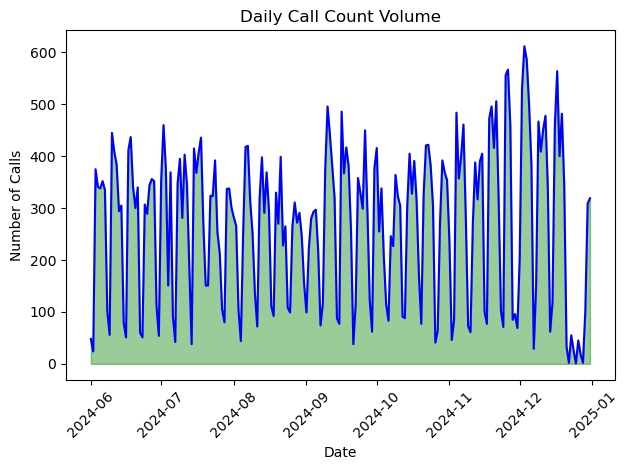

In [33]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'], color= 'blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color = 'green', alpha=0.4)

plt.title("Daily Call Count Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to
0,2024-06-01 09:06:00,Outbound,00:02:14,Oliver Martin
1,2024-06-01 09:25:00,Outbound,00:00:30,Garrett Evans
2,2024-06-01 10:00:00,Outbound,00:24:07,Keith Antonio
3,2024-06-01 10:07:00,NaN,00:27:46,Sam Steindorf
4,2024-06-01 10:16:00,Outbound,00:00:27,Garrett Evans


# Count of Call in Weekdays

In [38]:
df1['day'] = df1['Activity date'].dt.day_name()

In [40]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2024-06-01 09:06:00,Outbound,00:02:14,Oliver Martin,Saturday
1,2024-06-01 09:25:00,Outbound,00:00:30,Garrett Evans,Saturday
2,2024-06-01 10:00:00,Outbound,00:24:07,Keith Antonio,Saturday
3,2024-06-01 10:07:00,NaN,00:27:46,Sam Steindorf,Saturday
4,2024-06-01 10:16:00,Outbound,00:00:27,Garrett Evans,Saturday


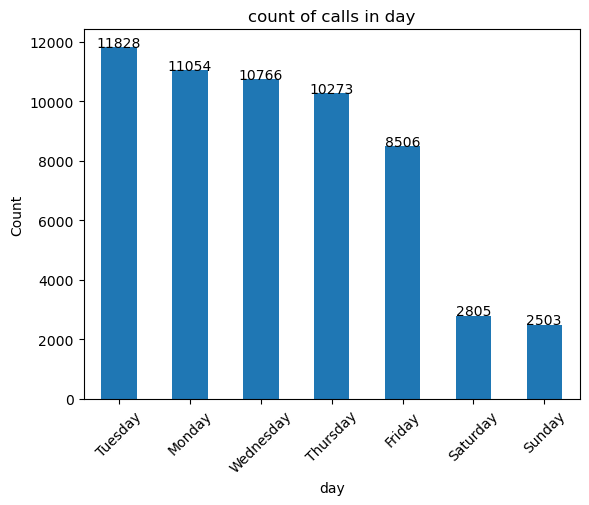

In [42]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax = day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i,v+1, str(v), ha= "center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

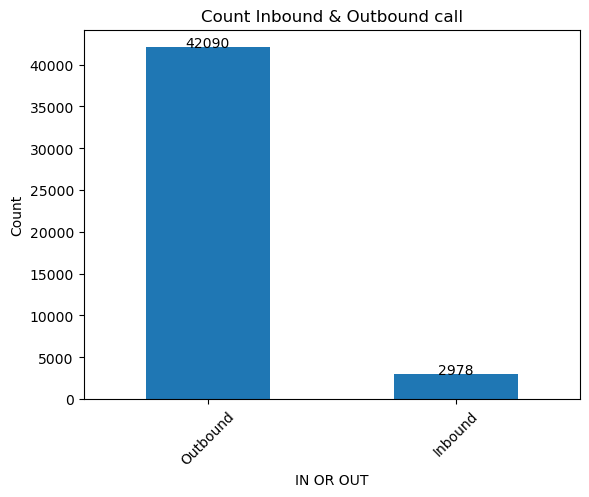

In [45]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i,v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel('IN OR OUT')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [48]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

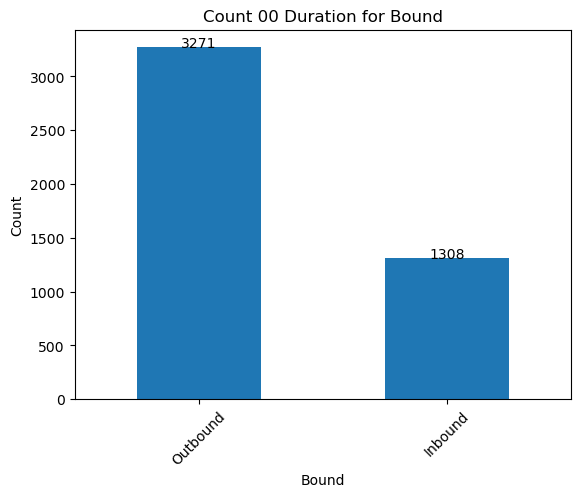

In [50]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have Call direction

In [53]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
450,2024-06-04 09:05:00,Outbound,NaN,Sam Steindorf,Tuesday
490,2024-06-04 11:09:00,Outbound,NaN,Cameron Dudley,Tuesday
494,2024-06-04 11:14:00,Outbound,NaN,Cameron Dudley,Tuesday
521,2024-06-04 11:43:00,Outbound,NaN,Cameron Dudley,Tuesday
806,2024-06-05 10:09:00,Outbound,NaN,Cameron Dudley,Wednesday
...,...,...,...,...,...
43097,2024-11-11 09:27:00,Outbound,NaN,David Valdez,Monday
45285,2024-11-18 15:39:00,Outbound,NaN,David Valdez,Monday
46880,2024-11-21 19:50:00,Outbound,NaN,David Valdez,Thursday
49981,2024-12-02 21:16:00,Outbound,NaN,Spenser Szakacs,Monday


In [55]:
df4 = df1.copy()

In [58]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [60]:
(df4['Call duration'] == 0).sum()

4579

In [62]:
df4['Call duration'].isnull().sum()

10109

In [64]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [66]:
df4 = df4.dropna(subset = ['Call direction'])

In [68]:
df4['Call duration'].isnull().sum()

0

In [70]:
df4['Call direction'].isnull().sum()

0

In [72]:
(df4['Call duration'] == 0).sum()

4647

In [74]:
df4.info()

<class 'pandas.DataFrame'>
Index: 45068 entries, 0 to 57734
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         45068 non-null  datetime64[us]
 1   Call direction        45068 non-null  str           
 2   Call duration         45068 non-null  float64       
 3   Activity assigned to  43768 non-null  str           
 4   day                   45068 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 3.2 MB


# Working Call Assigner

In [77]:
df1['Activity assigned to'].nunique()

27

In [79]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[    'Oliver Martin',     'Garrett Evans',     'Keith Antonio',
     'Sam Steindorf',      'David Valdez',                 nan,
        'Tyler Jury',      'Robin Stoehr',    'Cameron Dudley',
    'David Banister',     'Tanner Schunk',       'Paol Guzman',
      'Karen Parker',         'Terry Kim',      'Stephen Tarr',
      'Bill Goodwin',         'Juan Calo',  'Chrystel Manabat',
 'Brittany Digiulio',   'Adonis Baybayan',        'Henry Good',
    'Boston Hoppman',    'Kevin Vachhani',   'Spenser Szakacs',
        'Jesse Boyd',    'Nick Rothacher',       'Noah Burton',
       'Tyler Smith']
Length: 28, dtype: str

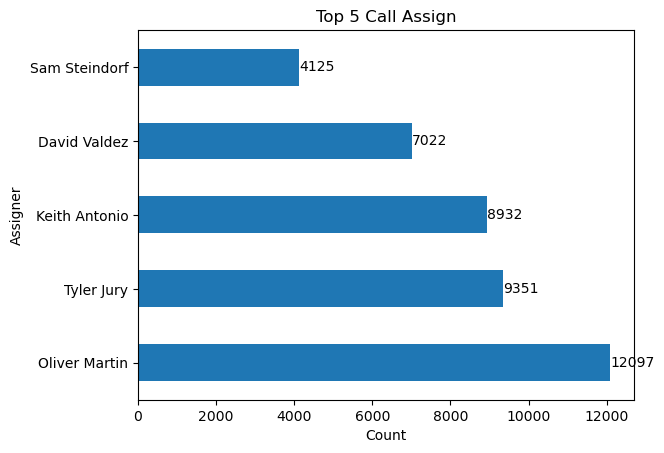

In [81]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [84]:
df4['Call duration'].max()

151.03333333333333

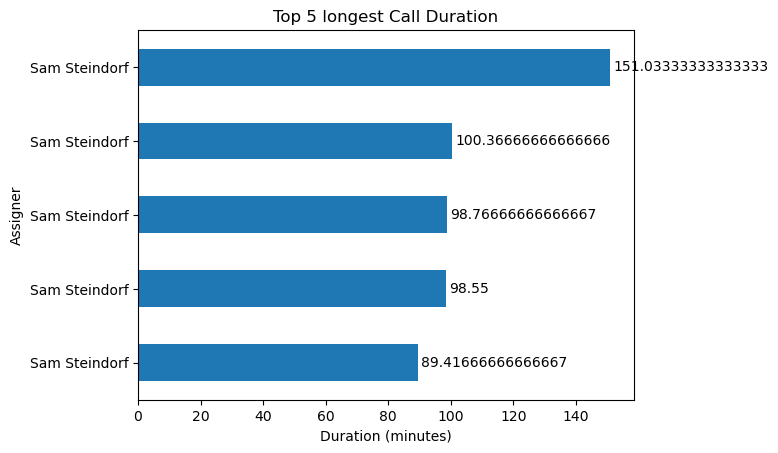

In [86]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Week days Call Volume

In [89]:
df3=df1.copy()

In [91]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [93]:
df3['day'].unique()

<ArrowStringArray>
['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Length: 5, dtype: str

In [95]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

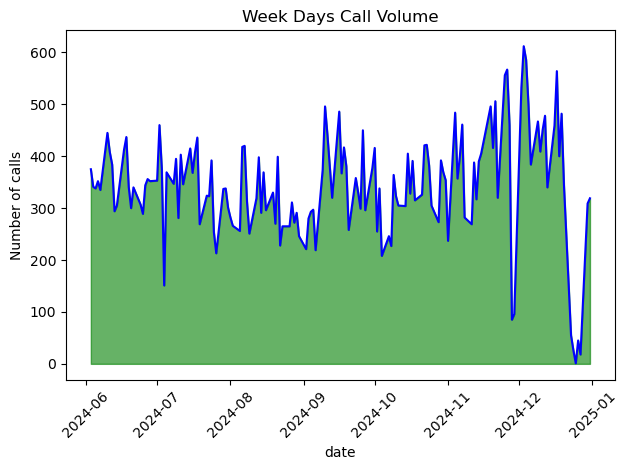

In [97]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [100]:
df5 = df4.copy()

In [102]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [104]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2024-06-01 09:06:00,Outbound,2.233333,Oliver Martin,Saturday
1,2024-06-01 09:25:00,Outbound,0.500000,Garrett Evans,Saturday
2,2024-06-01 10:00:00,Outbound,24.116667,Keith Antonio,Saturday
4,2024-06-01 10:16:00,Outbound,0.450000,Garrett Evans,Saturday
5,2024-06-01 10:24:00,Outbound,0.550000,Keith Antonio,Saturday


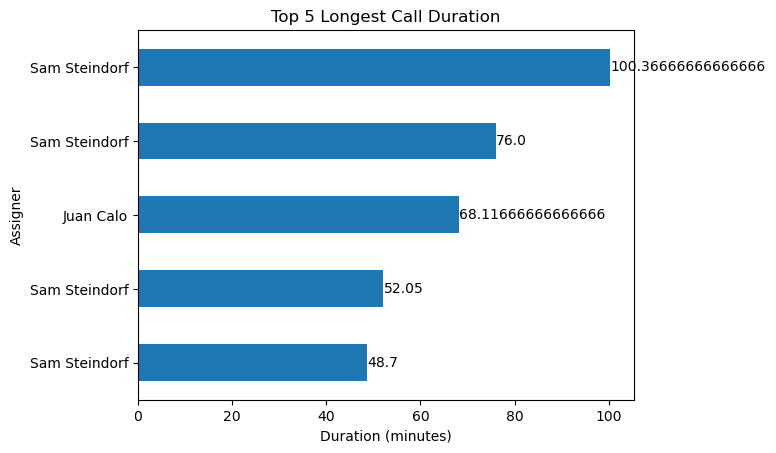

In [106]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend Call Assigner

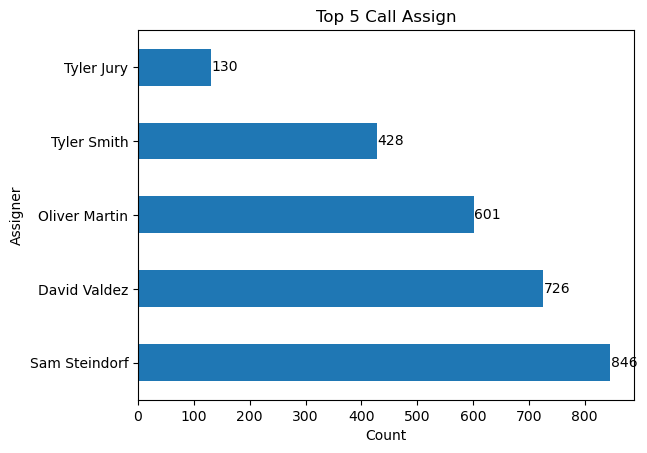

In [109]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Monthly Call Count

In [112]:
df6 = df3.copy()

In [114]:
df6['month'] = df6['Activity date'].dt.month_name()

In [116]:
df6.head()

,Activity date,Call direction,Call duration,Activity assigned to,day,month
72,2024-06-03 07:50:00,NaN,NaN,Keith Antonio,Monday,June
73,2024-06-03 07:51:00,NaN,NaN,Keith Antonio,Monday,June
74,2024-06-03 09:00:00,Outbound,00:00:31,Keith Antonio,Monday,June
75,2024-06-03 09:01:00,Outbound,00:05:22,Keith Antonio,Monday,June
76,2024-06-03 09:02:00,Outbound,00:02:05,David Valdez,Monday,June


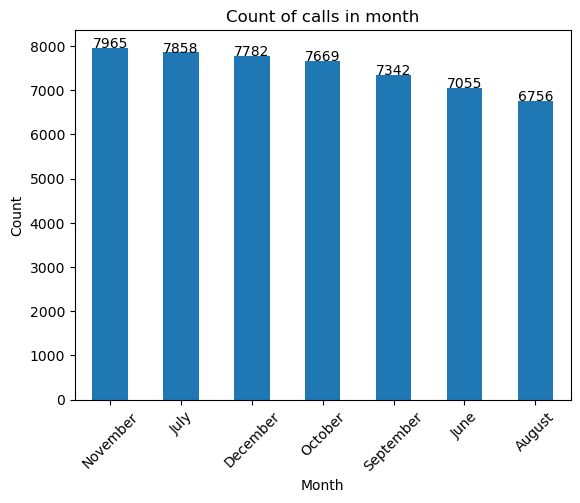

In [118]:
month_counts = df6["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls in month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# WITHOUT CALL ASSIGNER CALLS

In [121]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

In [123]:
no_assigner_calls.info()

<class 'pandas.DataFrame'>
Index: 1279 entries, 167 to 57707
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         1279 non-null   datetime64[us]
 1   Call direction        1195 non-null   str           
 2   Call duration         1277 non-null   str           
 3   Activity assigned to  0 non-null      str           
 4   day                   1279 non-null   str           
 5   month                 1279 non-null   str           
dtypes: datetime64[us](1), str(5)
memory usage: 106.2 KB


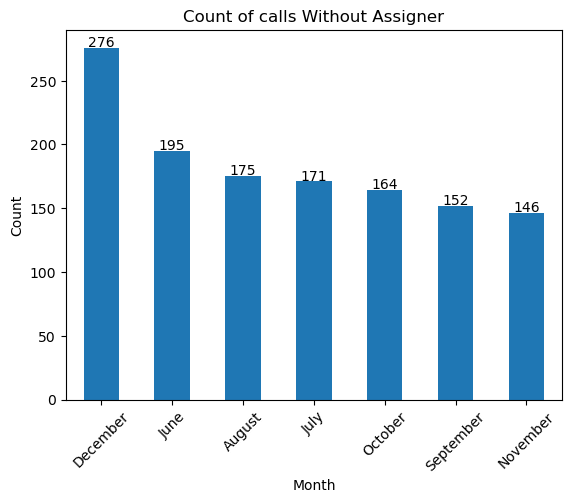

In [125]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top 5 Peak Call Date

In [128]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2024-06-01 09:06:00,Outbound,00:02:14,Oliver Martin,2024-06-01
1,2024-06-01 09:25:00,Outbound,00:00:30,Garrett Evans,2024-06-01
2,2024-06-01 10:00:00,Outbound,00:24:07,Keith Antonio,2024-06-01
3,2024-06-01 10:07:00,NaN,00:27:46,Sam Steindorf,2024-06-01
4,2024-06-01 10:16:00,Outbound,00:00:27,Garrett Evans,2024-06-01


In [130]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [132]:
top5 = daily_calls.sort_values(ascending=False).head(5)

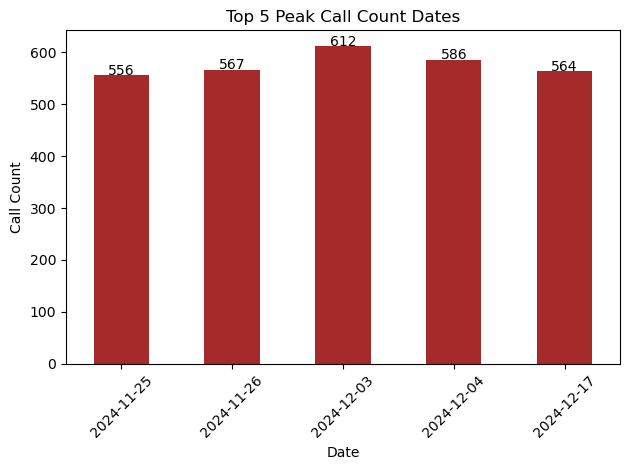

In [134]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count Dates")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()